<font size=6> **Travel Aggregator Analysis** </font>

# 🌴Project Aim


<font size=4>Objective</font>:

To enhance the performance and user experience of "Trip Away," a comprehensive travel aggregator, through in-depth data analysis.

<font size=4>Goals</font>:
1. **Analyze Customer Behavior**: Understand booking trends to tailor services to customer needs.
2. **Identify High-Demand Routes**: Predict peak travel times and popular destinations to optimize resource allocation.
3. **Detect Anomalies**: Identify and address fraudulent bookings or unusual price fluctuations to ensure platform integrity.
4. **Improve Conversion Rates**: Enhance the search-to-booking process to increase user engagement and transaction rates.
5. **Customer Retention & Marketing**: Develop strategies to retain loyal customers and optimize marketing efforts based on data insights.

This data-driven approach will leverage Python to extract valuable insights and provide actionable recommendations for improving the platform's efficiency and customer satisfaction.

# 🌴About the data

<font color=darkblue>*The analysis draws on data spanning a period of more than 3 years, 10 months, and 7 days.*</font>

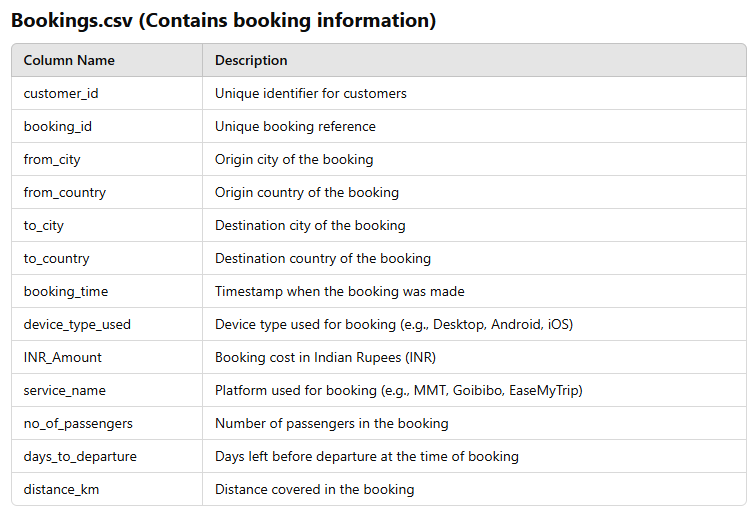

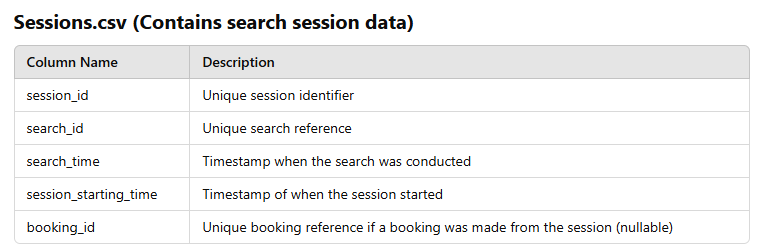

# 🌴Load Dependencies & Data

In [1]:
import pandas as pd
import numpy as np

import datetime

from matplotlib import pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
bookings = pd.read_csv("https://raw.githubusercontent.com/mcadriaans/eda_travel-aggregator/refs/heads/main/data/bookings.csv")
bookings.head()

,customer_id,booking_id,from_city,from_country,to_city,to_country,booking_time,device_type_used,INR_Amount,service_name,no_of_passengers,days_to_departure,distance_km
0,customer_259,booking_82,Gurgaon,India,Ahmedabad,India,2020-02-05T16:12:08Z,Desktop,2565.28,MMT,1.0,10.0,747.8
1,customer_303,booking_156,Delhi,India,Brussels,Belgium,2018-11-21T08:21:47Z,Android,23120.00,YATRA,1.0,1.0,6701.5
2,customer_203,booking_99,Devanhalli,India,Frankfurt am Main,Germany,2019-12-16T22:54:58Z,Android,25717.60,YATRA,1.0,32.0,7712.0
3,customer_211,booking_319,Gurgaon,India,Frankfurt am Main,Germany,2021-10-29T12:25:38Z,Desktop,135969.60,GOIBIBO,2.0,69.0,6112.5
4,customer_287,booking_222,Gurgaon,India,Roissy-en-France,France,2020-08-11T16:09:10Z,Android,31791.20,GOIBIBO,1.0,3.0,6570.4


In [4]:
sessions = pd.read_csv("https://raw.githubusercontent.com/mcadriaans/eda_travel-aggregator/refs/heads/main/data/sessions.csv")
sessions.head()

,session_id,search_id,search_time,session_starting_time,booking_id
0,session_322,search_784,2020-01-21T21:35:38.910Z,2020-01-21T21:10:12Z,NaN
1,session_322,search_776,2020-01-21T21:37:37.697Z,2020-01-21T21:10:12Z,NaN
2,session_322,search_623,2020-01-21T21:36:11.392Z,2020-01-21T21:10:12Z,NaN
3,session_322,search_270,2020-01-21T21:16:07.685Z,2020-01-21T21:10:12Z,NaN
4,session_322,search_905,2020-01-21T21:34:55.673Z,2020-01-21T21:10:12Z,NaN


## 🏖️ Glimpse the data

In [5]:
bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339 entries, 0 to 338
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        339 non-null    object 
 1   booking_id         339 non-null    object 
 2   from_city          339 non-null    object 
 3   from_country       339 non-null    object 
 4   to_city            339 non-null    object 
 5   to_country         339 non-null    object 
 6   booking_time       339 non-null    object 
 7   device_type_used   339 non-null    object 
 8   INR_Amount         339 non-null    float64
 9   service_name       339 non-null    object 
 10  no_of_passengers   339 non-null    float64
 11  days_to_departure  339 non-null    float64
 12  distance_km        339 non-null    float64
dtypes: float64(4), object(9)
memory usage: 34.6+ KB


<font size=4 color=#355E3B><b>Observations</b></font>

* No Missing Values.


In [6]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1497 entries, 0 to 1496
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   session_id             1497 non-null   object
 1   search_id              1497 non-null   object
 2   search_time            1497 non-null   object
 3   session_starting_time  1497 non-null   object
 4   booking_id             366 non-null    object
dtypes: object(5)
memory usage: 58.6+ KB


<font size=4 color=#355E3B><b>Observations</b></font>

Not every search session results in a booking. Users might search for travel options, compare prices, and then decide not to book. Therefore, the booking_id column is only populated when a booking is actually made.

#🌴 Exploratory Data Analysis

## 🏖️ 1. Count the number of distinct: Bookings, Sessions, Searches

In [7]:
print(f'There are {bookings["booking_id"].nunique()} unique bookings in the data.')

There are 339 unique bookings in the data.


In [8]:
print(f'There are {sessions["session_id"].nunique()} unique sessions in the data.')

There are 331 unique sessions in the data.


In [9]:
print(f'There are {sessions["search_id"].nunique()} unique searches in the data.')

There are 1360 unique searches in the data.


## 🏖️ 2. Identify sessions with multiple bookings

<font color=#355E3B>*Visualize the distribution of bookings per session using Histogram.*</font>




In [10]:
#ℹ️ Find bookings per session
bookings_per_session = sessions.groupby('session_id')['booking_id'].count().reset_index(name='nr_bookings')
#bookings_per_session

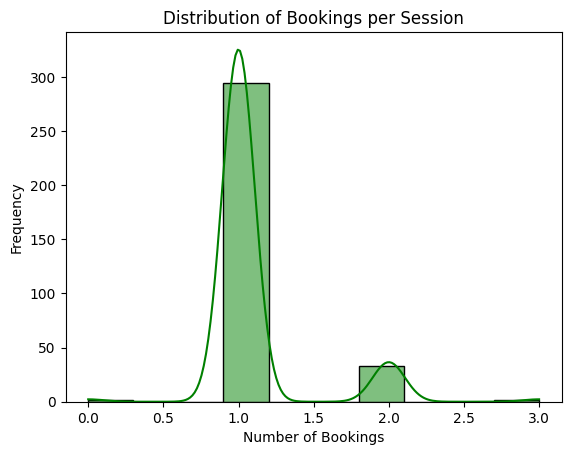

In [11]:
#ℹ️ Plot histogram
sns.histplot(bookings_per_session['nr_bookings'], kde=True, color='green')
plt.title('Distribution of Bookings per Session')
plt.xlabel('Number of Bookings')
plt.ylabel('Frequency')
plt.show()

<font size=4 color=#355E3B><b>Key Insights</b></font>

Most sessions contain a single booking, while a small number include two bookings, and only one session reaches three bookings.
The sharp peak at one booking indicates that users typically complete a single transaction per visit, suggesting that multi‑booking behavior is rare and may represent special cases such as group or repeat purchases.

## 🏖️ 3. Analyze booking trends

<font color=#355E3B>*Determine the days of the week with the highest number of bookings.*</font>

In [12]:
# ℹ️ Convert booking_time to datetime object
bookings['booking_time'] = pd.to_datetime(bookings['booking_time'])
# ℹ️ Extract weekday from booking_time
bookings['weekday'] = bookings['booking_time'].dt.strftime('%A')

In [13]:
# ℹ️ Count the number of bookings by weekday
bookings_per_weekday = bookings['weekday'].value_counts().reset_index()

print(f'The day of the week with the highest number of bookings is {bookings_per_weekday.head(1)["weekday"].values[0]}. ')
print(f'It has a total of {bookings_per_weekday["count"].values[0]} bookings.')


The day of the week with the highest number of bookings is Thursday. 
It has a total of 65 bookings.


<font color=#355E3B>*Visualize this distribution using a pie chart.*<font>

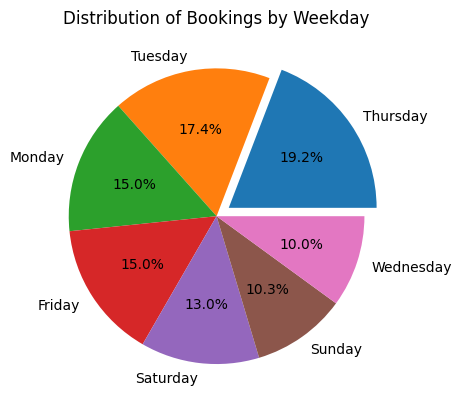

In [14]:
# ℹ️ Find the index of the highest value
max_index = bookings_per_weekday['count'].idxmax()

# ℹ️ Create explode list
explode = [0.1 if i == max_index else 0 for i in range(len(bookings_per_weekday))]

# ℹ️ Create pie chart
plt.pie(bookings_per_weekday['count'], labels=bookings_per_weekday['weekday'], autopct='%1.1f%%', explode=explode)
plt.title('Distribution of Bookings by Weekday')
plt.show()

<font size=4 color=#355E3B><b>Key Insights</b></font>

* Thursday records the highest share of bookings (19.2%), making it the most popular day.
* Saturday and Sunday together account for 23.3% of total bookings. This is lower than the 28.6% (2 weekends/7 days) expected if bookings were evenly distributed across the seven days, suggesting that bookings are relatively more concentrated on weekdays than weekends.

## 🏖️ 4. Service Performance Analysis

<font color=#355E3B>*Calculate the total number of bookings and the Gross Booking Value (INR) for each service name.*<font>





In [15]:
service_name_aggregations = bookings.groupby("service_name"). agg({
    'booking_id' : ['count'],
    'INR_Amount' : ['sum']}).reset_index()

# ℹ️ Update column names
service_name_aggregations.columns = ['service_name', 'total_bookings', 'revenue(INR)']
#service_name_aggregations

<font color=#355E3B>*Visualize using Bar chart comparing total bookings and revenue per service.*</font>


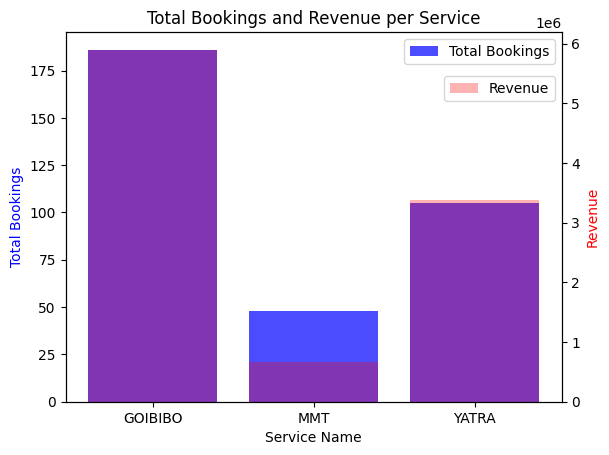

In [16]:
# ℹ️ Create a figure and a set of subplots
fig, ax1 = plt.subplots()

# ℹ️ Plot the total bookings
ax1.bar(service_name_aggregations['service_name'], service_name_aggregations['total_bookings'], color='b', alpha=0.7, label='Total Bookings')

# ℹ️ Create a twin Axes sharing the x-axis
ax2 = ax1.twinx()

# ℹ️ Plot the revenue
ax2.bar(service_name_aggregations['service_name'],service_name_aggregations['revenue(INR)'], color='r', alpha=0.3, label='Revenue')

# ℹ️ Add labels
ax1.set_xlabel('Service Name')
ax1.set_ylabel('Total Bookings', color='b')
ax2.set_ylabel('Revenue', color='r')

# ℹ️ Add a title
plt.title('Total Bookings and Revenue per Service')

# ℹ️ Add legends
ax1.legend(loc='upper right')
ax2.legend(loc='upper right', bbox_to_anchor=(1.0,0.9))

# ℹ️ Show the plot
plt.show()


<font color=darkslategray>*The axes are independent and should not be interpreted as directly comparable values. The purpose of the dual axis is to visualize both metrics side by side, not to imply they share the same unit or magnitude.*</font>

<font size=4 color=#355E3B><b>Key Insights</b></font>

* **GOIBIBO** leads with the highest total bookings and revenue, indicating strong market presence and effective customer acquisition.

* **MMT (MakeMyTrip)** shows the lowest revenue (under 1 million) and fewest bookings, suggesting challenges in conversion or pricing strategy.

* **YATRA** maintains moderate performance in both metrics, reflecting a stable but smaller market share.

## 🏖️ 5. Most Popular Routes

<font color=#355E3B>*Identify the most booked route (from_city to to_city) for customers who have more than one booking.*</font>

In [17]:
# ℹ️ Counting total bookings per customer
bookings_by_customers = bookings['customer_id'].value_counts().reset_index(name='total_bookings')
# ℹ️ Filtering customers with more than one booking.
customers_multiple_bookings = bookings_by_customers[bookings_by_customers['total_bookings'] > 1]

# ℹ️ Filter bookings to only include customers listed in customers_multiple_bookings
bookings_filtered = bookings[bookings['customer_id'].isin(customers_multiple_bookings['customer_id'])]

In [18]:
# ℹ️ Counting the number of bookings for each city pair
route_bookings_count = bookings_filtered.groupby(['from_city', 'to_city'])['booking_id'].count().reset_index(name='total_bookings')
# Sorting the results and displaying the top routes
route_bookings_count.sort_values(by='total_bookings', ascending=False, inplace=True)

<font color=#355E3B>*Visualize the top 5 routes displayed in a horizontal bar chart.*</font>

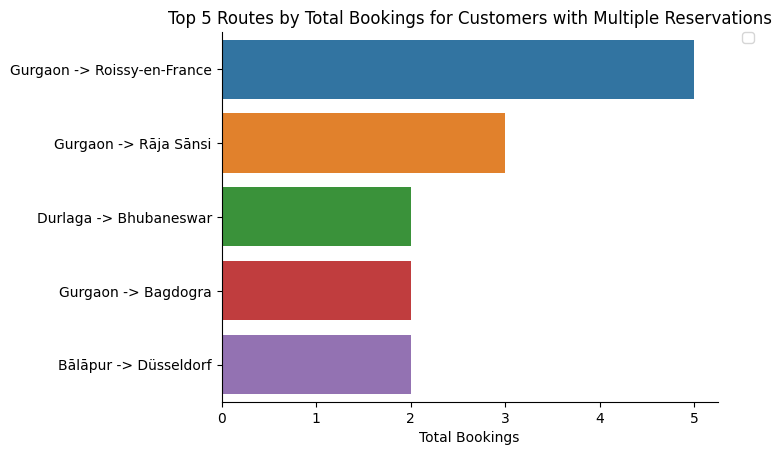

In [19]:
# ℹ️ Create a route column
route_bookings_count['route'] = route_bookings_count['from_city'] + ' -> ' + route_bookings_count['to_city']

# ℹ️ Create bar chart
ax = sns.barplot(data=route_bookings_count.head(), x='total_bookings', y='route', hue='route')

# ℹ️ Remove axis spines top and right
sns.despine()

# ℹ️ Update plot layout
plt.title('Top 5 Routes by Total Bookings for Customers with Multiple Reservations')
plt.xlabel('Total Bookings')
plt.ylabel('')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.show()

<font size=4 color=#355E3B><b>Key Insights</b></font>

* **Repeat travelers concentrate around Gurgaon**, which appears in three of the top five routes, confirming its role as a major origin hub.

* The **Gurgaon → Roissy-en-France route** leads all others, suggesting strong international travel demand or frequent business connections between these cities.

* Secondary routes such as **Gurgaon → Rāja Sānsī** and **Durlaga → Bhubaneswar** indicate regional travel patterns, possibly tied to domestic business or leisure trips.

Repeat bookings cluster around a small number of popular routes, rather than being spread evenly across many destinations.

## 🏖️ 6. Advanced Booking Patterns

<font color=#355E3B>*Determine the top 3 departure cities where customers book significantly in advance (only consider cities with at least 5 departures).*</font>

In [20]:
# ℹ️Count the departures per city
departures_per_city = bookings.groupby(by='from_city')['booking_id'].count().reset_index(name='total_departures')

# ℹ️ Filter and reset index for cities with 5+ departures
departures_per_city_more_than_5 = departures_per_city[departures_per_city['total_departures'] >= 5].reset_index(drop=True)

# Filter bookings for cities with 5+ departures
departures_per_city_more_than_5_filtered = bookings[bookings['from_city'].isin(departures_per_city_more_than_5['from_city'])]

cities_days_to_depart = departures_per_city_more_than_5_filtered[['from_city', 'days_to_departure']]

# ℹ️ Get top 3 longest advanced bookings
top_3_longest_advanced_bookings= cities_days_to_depart.sort_values(by='days_to_departure', ascending=False).reset_index().head(3)
top_3_longest_advanced_bookings

,index,from_city,days_to_departure
0,71,Gurgaon,311.0
1,230,Devanhalli,226.0
2,212,Mumbai,218.0


<font color=#355E3B>*Use Box plot showing days to departure for different cities.*</font>

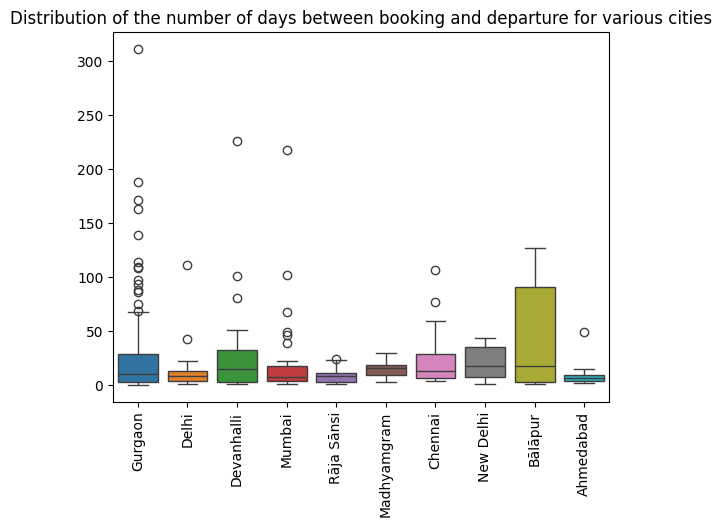

In [21]:
# ℹ️ Create a Boxplot
sns.boxplot(data=departures_per_city_more_than_5_filtered, x='from_city', y='days_to_departure', hue='from_city')
plt.xticks(rotation=90)
plt.title('Distribution of the number of days between booking and departure for various cities')
plt.xlabel('')
plt.ylabel('')
plt.show()

<font size=4 color=#355E3B><b>Key Insights</b></font>

* **Short-Term Bookings Dominate**: Most cities (Delhi, Mumbai, Raja Sānsī, Madhyamgram, Chennai, New Delhi, and Ahmedabad) show bookings made close to the departure date, indicating spontaneous or short-notice travel behavior.

* **Early Planning Hubs: Gurgaon and Devanhalli** display wider variability and longer lead times, suggesting that travelers from these cities tend to plan trips further in advance.

* **Bālāpur's Distinct Pattern**: Bālāpur stands out with consistently long booking lead times and a high median, implying unique travel characteristics such as event-based travel, limited flight availability, or organized group trips.

* **Outlier Behavior**: The presence of extreme values across several cities shows that a subset of travelers consistently plan well ahead, regardless of city trends.

## 🏖️ 7. Correlation Analysis

<font color=#355E3B>*Plot a heatmap displaying the correlation between numerical columns in the bookings dataset.*</font>

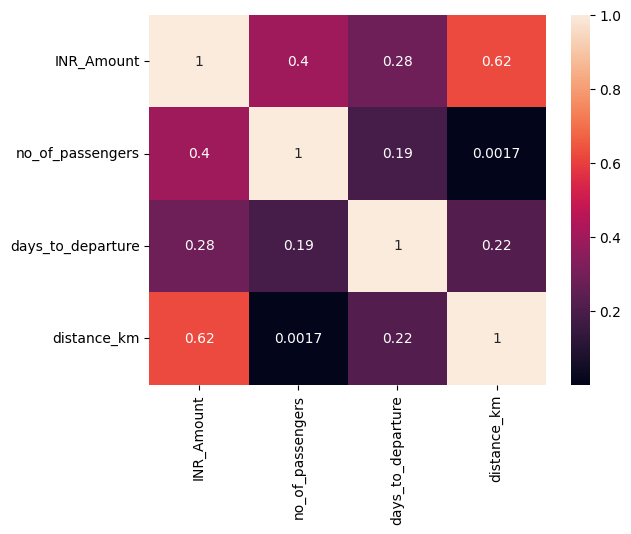

In [22]:
num_cols = [c for c in bookings.columns if bookings[c].dtype == 'float64']

sns.heatmap(bookings[num_cols].corr(), annot=True)
plt.show()

<font size=4 color=#355E3B><b>Key Insights</b></font>


* Longer travel distances are strongly linked to higher booking costs, confirming that **distance is a major driver of total fare**.

* The number of passengers shows a moderate positive relationship with cost, meaning **group or family bookings tend to increase total spending**.

* The weak correlations between booking lead time and other variables suggest that **how early customers book doesn't significantly affect price or distance**.

* Overall, the data indicates that **distance and passenger count are the most influential factors** in determining booking value.

## 🏖️ 8. Device Preferences

<font color=#355E3B>*Identify the most used device type for bookings for each service provider.*</font>

In [23]:
# ℹ️ Count total bookings by service name and device type
service_device_booking_count = bookings.groupby(by=['service_name', 'device_type_used'])['booking_id'] \
                                      .count().reset_index(name='total_bookings')
#service_device_booking_count

<font color=#355E3B>*Visualize using Stacked bar chart for device usage per service provider.*</font>

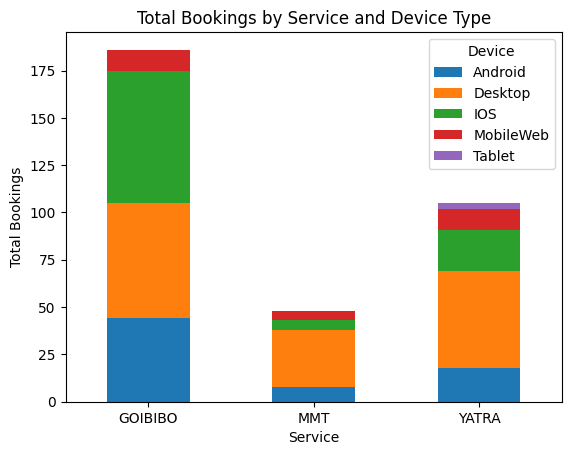

In [24]:
#ℹ️ Pivot the dataframe
df_pivot = service_device_booking_count.pivot(index='service_name', columns='device_type_used', values='total_bookings')
df_pivot

# ℹ️ Plot the stacked bar chart
df_pivot.plot(kind='bar', stacked=True)
plt.xlabel('Service')
plt.ylabel('Total Bookings')
plt.title('Total Bookings by Service and Device Type')
plt.legend(title='Device')
plt.xticks(rotation=360)
plt.show()


<font size=4 color=#355E3B><b>Key Insights</b></font>

* **GOIBIBO** leads in total bookings and shows the most diverse device usage, with strong engagement from iOS, desktop, and Android users.

* **MMT** relies heavily on desktop users, suggesting a more traditional or work-based booking pattern.

* **YATRA** maintains balanced usage across desktop and Android platforms, indicating broader accessibility and appeal to mobile users.

* **Tablet usage** remains minimal across all services, showing limited adoption for travel bookings on that device type.

## 🏖️ 9. Quarterly Booking Trends

<font color=#355E3B>*Plot a time series analysis showing the number of bookings per quarter, categorized by device type.*</font>

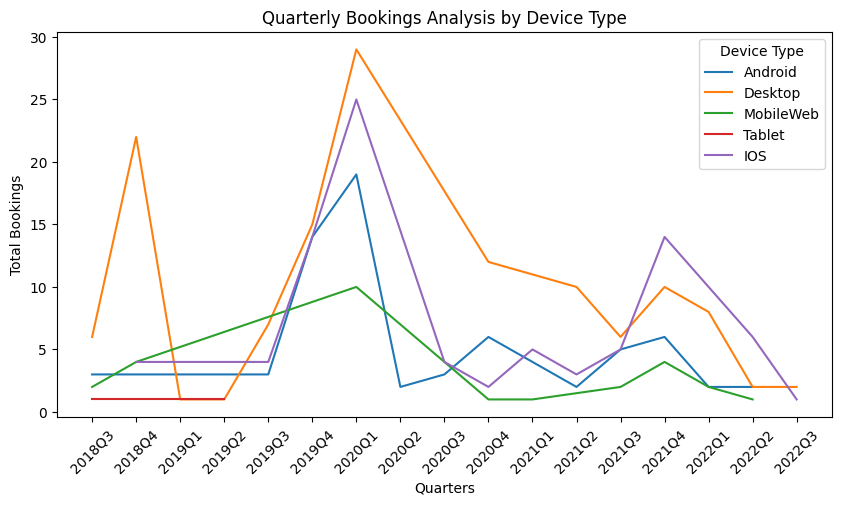

In [25]:
# ℹ️ Convert booking time to quarter format and store as string
bookings['quarter'] = bookings['booking_time'].dt.to_period('Q').astype(str)

# ℹ️ Find the number of bookings per quarter, categorized by device type.
bookings_per_quarter_device = bookings.groupby(['quarter', 'device_type_used'])['booking_id'].count()
bookings_per_quarter_device = bookings_per_quarter_device.reset_index(name='total_bookings')

# ℹ️ Create a line plot showing quarterly bookings by device type
bookings_per_quarter_device = bookings.groupby(['quarter', 'device_type_used'])['booking_id'].count()
bookings_per_quarter_device = bookings_per_quarter_device.reset_index(name='total_bookings')
plt.figure(figsize=(10, 5))
sns.lineplot(data=bookings_per_quarter_device, x='quarter', y='total_bookings', hue='device_type_used')
plt.title('Quarterly Bookings Analysis by Device Type')
plt.legend(title='Device Type')
plt.ylabel('Total Bookings')
plt.xlabel('Quarters')
plt.xticks(rotation=45)
plt.show()

<font size=4 color=#355E3B><b>Key Insights</b></font>


* **Desktop and iOS bookings** peaked sharply in early 2020, likely reflecting strong pre-pandemic travel activity before a noticeable decline in subsequent quarters.

* **Android and Mobile Web** showed steady growth until Q1 2020, then gradually decreased, suggesting a shift in user behavior or reduced travel demand after that period.

* **Tablet usage** remained consistently low across all quarters, confirming minimal engagement from this device type.

* Overall, the data reveals a clear surge in bookings around Q1 2020 across most devices, followed by a steady decline. This pattern that aligns with major market disruptions during that time.

## 🏖️ 10. Calculate the overall booking-to-search ratio (oBSR)

$\text{oBSR} = \frac{\text{Total Bookings}}{\text{Total Searches}}$

In [26]:
# ℹ️ Merge the two datasets
merged = pd.merge(sessions, bookings, on='booking_id', how='left')

# ℹ️ Convert 'search_time' to datetime
merged['search_time'] = pd.to_datetime(merged['search_time'], format='ISO8601', errors='coerce')

merged['date'] = merged['search_time'].dt.date
merged['weekday'] = merged['search_time'].dt.strftime('%A')

# ℹ️ Aggregate total bookings, searches, and customers by date
daily_summary = merged.groupby(by='date').agg(
        total_bookings=('booking_id', 'nunique'),
    total_searches=('search_id', 'nunique'),
        total_customers = ('customer_id', 'nunique')
).reset_index()

# ℹ️ Calculate oBSR as the ratio of total bookings to total searches
daily_summary['oBSR'] = np.round(daily_summary['total_bookings'] / daily_summary['total_searches'], 2)

# ℹ️ Create a Plotly line chart
fig = px.line(daily_summary, x='date', y='oBSR', color_discrete_sequence=['darkgoldenrod'])

# ℹ️ Customize the layout
fig.update_layout(
    xaxis_title='Date',
    yaxis_title=' ',
    title={
       'text': 'Overall Booking-to-Search Ratio',
        'x': 0.5,
        'xanchor': 'center'
    }
)

# ℹ️ Show the plot
fig.show()

<font size=4 color=#355E3B><b>Key Insights</b></font>

* The oBSR fluctuates sharply over time, showing periods of high conversion where nearly every search led to a booking, followed by intervals of low engagement.

* Peaks around mid-2019 and early 2020 suggest strong booking activity relative to search volume, possibly driven by seasonal travel demand or promotional campaigns.

* The frequent dips indicate inconsistent conversion performance, which may reflect changes in pricing, competition, or user behavior.

* Overall, the ratio's volatility highlights that search interest doesn't always translate into bookings, emphasizing the need for steady optimization of the booking funnel.

<font color=#355E3B>*What is the average of oBSR for each month of the year?*</font>

In [27]:
# ℹ️ Extract the month from the 'date' column and map it to month names
daily_summary['month'] = pd.to_datetime(daily_summary['date']).dt.month
# map month to month name
month_mapping = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

daily_summary['month']= daily_summary['month'].map(month_mapping)

# ℹ️ Calculate the mean oBSR for each month
avg_monthly_oBSR = np.round(daily_summary.groupby('month')['oBSR'].mean(), 2).reset_index(name = 'avg_monthly_oBSR')

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# ℹ️ Sort the DataFrame by the defined month order
avg_monthly_oBSR['month']= pd.Categorical(avg_monthly_oBSR['month'], categories=month_order, ordered=True)
avg_monthly_oBSR = avg_monthly_oBSR.sort_values(by='month')


# ℹ️ Create a Plotly line chart
fig = px.line(avg_monthly_oBSR, x='month', y='avg_monthly_oBSR',color_discrete_sequence=['green'])

# ℹ️ Customize the layout
fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Average oBSR',
    title={
       'text': 'Average oBSR for Each Month',
        'x': 0.5,
        'xanchor': 'center'
    }
)

# ℹ️ Show the plot
fig.show()

<font size=4 color=#355E3B><b>Observations</b></font>
* The highest average oBSR occurs in June and September, indicating strong performance in these months.
* A sharp decline is seen in July, marking the lowest point in the dataset.

<font size=4 color=#355E3B><b>Key Insights</b></font>

* The average booking-to-search ratio (oBSR) fluctuates throughout the year, showing distinct seasonal patterns.

* **June and September** record the highest oBSR values, suggesting stronger conversion rates during mid-year travel seasons.

* **July** shows the lowest oBSR, indicating reduced conversion efficiency, possibly due to high search activity without corresponding bookings.

* Early months like **February** and late months like **November** maintain moderate ratios, reflecting steady but less pronounced booking performance.

* Overall, the data suggests that mid-year periods drive the most effective conversion from search to booking, while summer months may require targeted engagement strategies.

<font color=#355E3B>*What is the average of oBSR for each day of week?*</font>

In [28]:
# Convert the 'date' column to datetime format and extract the weekday name
daily_summary['weekday'] = pd.to_datetime(daily_summary['date']).dt.day_name()

# ℹ️ Calculate the mean oBSR for each day of the week
avg_daily_oBSR = np.round(daily_summary.groupby('weekday')['oBSR'].mean(), 2).reset_index(name = 'avg_daily_oBSR')

weekday_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

# ℹ️ Sort the DataFrame by the defined month order
avg_daily_oBSR['weekday']= pd.Categorical(avg_daily_oBSR['weekday'], categories=weekday_order, ordered=True)
avg_daily_oBSR = avg_daily_oBSR.sort_values(by='weekday')

# ℹ️ Create a Plotly line chart
fig = px.line(avg_daily_oBSR, x='weekday', y='avg_daily_oBSR', title='Average Daily oBSR',
              color_discrete_sequence=['purple'])

# ℹ️ Customize the layout
fig.update_layout(
    xaxis_title='Weekday',
    yaxis_title='Average oBSR',
    title={
       'text': 'Average oBSR for Each Day',
        'x': 0.5,
        'xanchor': 'center'
    }
)

# ℹ️ Show the plot
fig.show()

<font size=4 color=#355E3B><b>Key Insights</b></font>


* The average booking-to-search ratio (oBSR) varies across the week, showing distinct daily patterns.

* **Tuesday** records the highest oBSR, indicating stronger conversion rates and more decisive booking behavior early in the week.

* **Wednesday** shows the lowest oBSR, suggesting reduced conversion efficiency, possibly due to mid-week browsing or comparison activity.

* **Saturday and Sunday** maintain relatively high ratios, reflecting stronger weekend engagement and higher likelihood of completing bookings.

* Overall, the data suggests that early-week and weekend periods are the most effective for driving conversions, while mid-week may require targeted strategies to boost booking rates.

## 🏖️ 11. Customer Segmentation

<font color=#355E3B>*Bin customers based on booking frequency* </font>

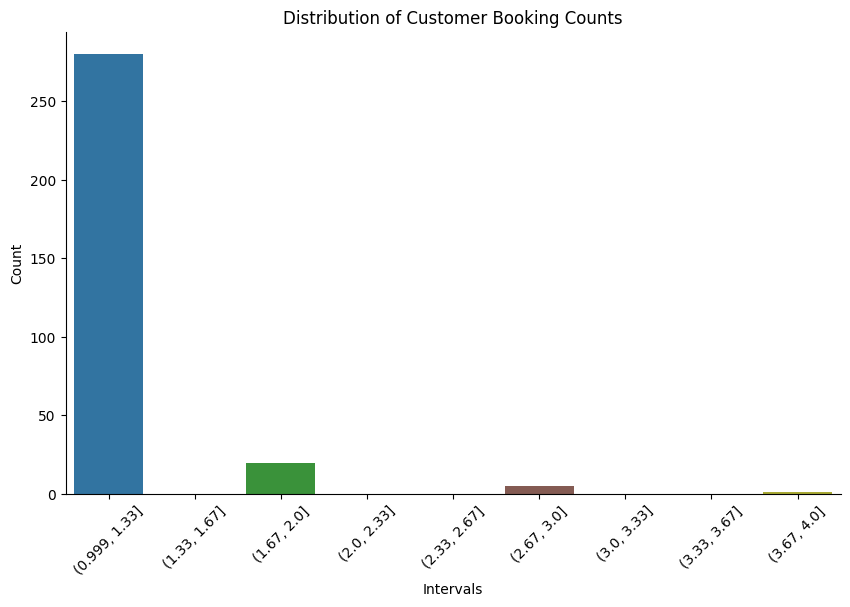

In [29]:
customer_booking_counts = bookings['customer_id'].value_counts().reset_index()

# ℹ️ Calculate the minimum and maximum values
min_value = customer_booking_counts['count'].min()
max_value = customer_booking_counts['count'].max()

# ℹ️ Total number of data points
N = len(customer_booking_counts)
# ℹ️ Sturges' Rule
num_bins = int(1 + np.log2(N))

# ℹ️ Calculate the bin width
bin_width = (max_value - min_value) / num_bins

# ℹ️ Create the bin edges and round them to 2 decimal points
bin_edges = [round(min_value + i * bin_width, 2) for i in range(num_bins + 1)]

# ℹ️ Assign intervals to booking counts
customer_booking_counts['intervals'] = pd.cut(customer_booking_counts['count'], bins=bin_edges, include_lowest=True)

interval_counts = customer_booking_counts['intervals'].value_counts().reset_index()

# ℹ️ Draw a barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=interval_counts, x='intervals', y ='count', hue='intervals')
sns.despine()
plt.title('Distribution of Customer Booking Counts')
plt.xlabel('Intervals')
plt.ylabel('Count')
plt.legend().remove()
plt.xticks(rotation=45)
plt.show()

<font size=4 color=#355E3B><b>Key Insights</b></font>
* The distribution of booking counts is heavily skewed, with the vast majority of customers making only **one booking**.

* A small fraction of users book two or more times, and repeat bookings drop sharply beyond that point.

* This pattern indicates a high proportion of one-time customers, suggesting limited repeat engagement or loyalty.

* The long tail of low-frequency repeat customers highlights potential for growth through retention strategies.

<font color=#355E3B>*Bin customers based on total amount spent* </font>

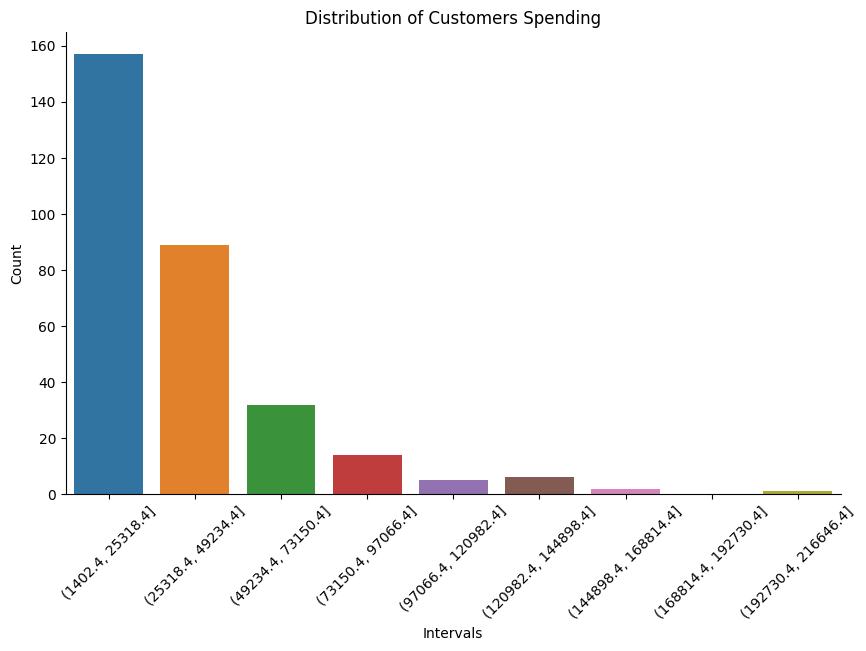

In [30]:
total_amount_per_customer = bookings.groupby('customer_id')['INR_Amount'].sum().reset_index(name='total_amount')

# ℹ️ Calculate the minimum and maximum values
min_value = total_amount_per_customer['total_amount'].min()
max_value = total_amount_per_customer['total_amount'].max()

# ℹ️ Calculate the bin width
bin_width = (max_value - min_value) / num_bins

# ℹ️ Create the bin edges and round them to 2 decimal points
bin_edges = [round(min_value + i * bin_width, 2) for i in range(num_bins + 1)]

# ℹ️ Assign intervals to booking counts
total_amount_per_customer['intervals'] = pd.cut(total_amount_per_customer['total_amount'], bins=bin_edges, include_lowest=True)

#  ℹ️ Round interval bounds to two decimal places
total_amount_per_customer['intervals'] = total_amount_per_customer['intervals'].apply(lambda x: f'({round(x.left, 2)}, {round(x.right, 2)}]')

#  ℹ️ Calculate the counts of each interval and reset the index
interval_counts = total_amount_per_customer['intervals'].value_counts().reset_index()

#  ℹ️ Draw a barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=interval_counts, x='intervals', y ='count', hue='intervals')
sns.despine()
plt.title('Distribution of Customers Spending')
plt.xlabel('Intervals')
plt.ylabel('Count')
plt.legend().remove()
plt.xticks(rotation=45)
plt.show()


<font size=4 color=#355E3B><b>Key Insights</b></font>

* The majority of customers fall within the lowest spending range (INR 1.4K-INR 25K), indicating that most transactions are relatively small.

* A smaller segment spends between INR 25K-INR 75K, showing moderate engagement and potential for upselling.

* Very few customers spend above INR 1 lakh, highlighting a small but valuable high-spending group.

* The overall distribution is right-skewed, meaning spending is concentrated among lower-value customers with a long tail of high-value outliers.

## 🏖️ 12. Fraudulent Booking Detection

<font color=#355E3B>*Identify unusual bookings with extreme price values.*</font>

In [31]:
#  ℹ️ Define outlier threshold
price_mean = round(np.mean(bookings['INR_Amount']),2)
price_std = round(np.std(bookings['INR_Amount']),2)
threshold = price_mean + 3 * price_std

extreme_prices = bookings[bookings['INR_Amount'] > threshold]

<font color=#355E3B>*Visualize a scatter plot to visualize booking prices vs. number of passengers.*</font>

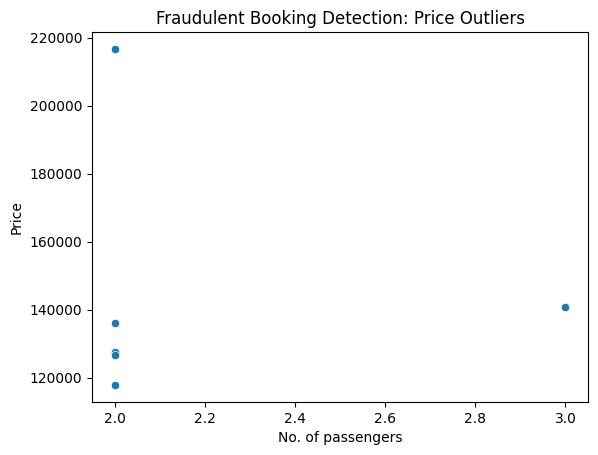

In [32]:
#  ℹ️ Create a scatterplot
sns.scatterplot(data=extreme_prices, x='no_of_passengers', y='INR_Amount')
plt.title('Fraudulent Booking Detection: Price Outliers')
plt.xlabel('No. of passengers')
plt.ylabel('Price')
plt.show()


<font size=4 color=#355E3B><b>Key Insights</b></font>


* A few bookings show **extremely high prices (above INR 1.2 lakh)** compared to the typical range, marking them as potential outliers.

* These outliers mostly occur for bookings with **two passengers**, with one notable case at **three passengers**, suggesting that passenger count alone does not explain the price anomaly.

* The sharp deviation from the mean price indicates possible **data entry errors**, **system glitches**, or **fraudulent transactions**.

* Overall, the scatterplot effectively isolates high-value anomalies for further investigation.

## 🏖️ 13. Price Sensitivity Analysis

<font color=#355E3B>*Analyze how fluctuations in fare prices affect booking rates.*</font>

In [33]:
price_bins = pd.cut(bookings['INR_Amount'], bins=10)
price_sensitivity = bookings.groupby(price_bins)['booking_id'].count().reset_index()
price_sensitivity.columns = ['price_range', 'booking_count']

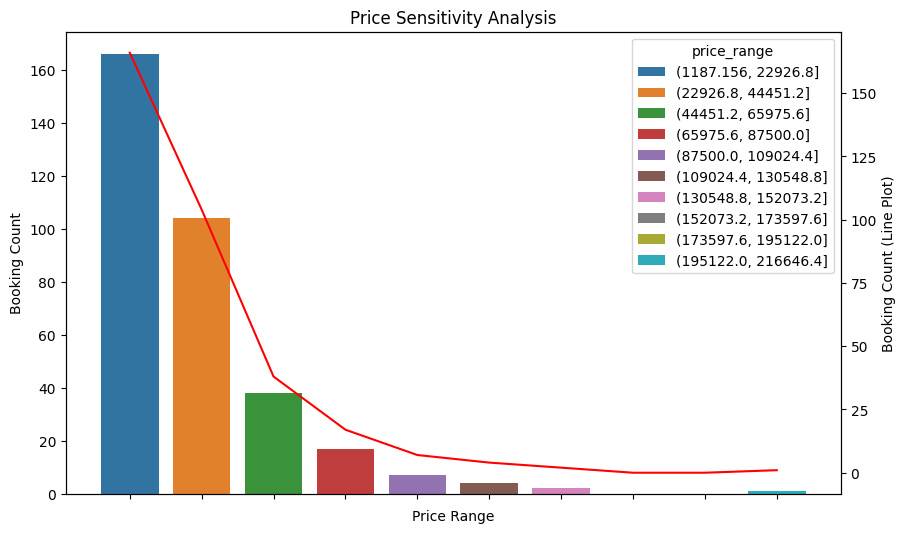

In [34]:
#  ℹ️Plot bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=price_sensitivity, x='price_range', y='booking_count', hue='price_range')
plt.title('Price Sensitivity Analysis')
plt.xlabel('Price Range')
plt.ylabel('Booking Count')

# ℹ️ Remove xtick labels
ax.set_xticklabels([])

# ℹ️ Create a second y-axis for the line plot
ax2 = ax.twinx()
# Convert the categorical data in the 'price_range' column into numerical codes
price_sensitivity['price_range_num'] = price_sensitivity['price_range'].cat.codes
# Use the numerical representation for the line plot
sns.lineplot(data=price_sensitivity, x='price_range_num', y='booking_count', ax=ax2, color='red')
ax2.set_ylabel('Booking Count (Line Plot)')

plt.show()

<font size=4 color=#355E3B><b>Key Insights</b></font>


* The analysis shows a **strong inverse relationship** between fare price and booking count; as prices increase, bookings drop sharply.

* The **lowest price range (INR 1.1K-INR 23K)** attracts the highest number of bookings, confirming that customers are highly price-sensitive.

* Mid-range prices **(INR 23K-INR 65K)** see moderate engagement, while bookings decline steeply beyond **INR 65K**, indicating limited demand for premium fare tiers.

* The red line trend reinforces that booking activity decreases almost exponentially with rising prices, highlighting clear thresholds for optimal pricing.

## 🏖️ 14. Search Abandonment Analysis

<font color=#355E3B>*Use a  Funnel chart to visualize search-to-booking drop-off.*</font>

In [35]:
abandoned_searches = len(sessions[sessions['booking_id'].isnull()])
total_searched = len(sessions)
abandoned_search_rate = round((abandoned_searches / total_searched) * 100, 2)
completed_bookings = total_searched - abandoned_searches

print(f'The abandoned search rate for searches that do not end in bookings is {abandoned_search_rate:.0f}%.')

The abandoned search rate for searches that do not end in bookings is 76%.


In [36]:
# ℹ️ Prepare data for the funnel chart
stages = ['Search', 'Complete Booking']
counts = [total_searched, completed_bookings]

funnel_data = {
    'stages': stages,
    'counts': counts
}

# ℹ️ Create the funnel chart using Plotly
fig = go.Figure(go.Funnel(
    y=funnel_data['stages'],
    x=funnel_data['counts'],
    textinfo="value+percent initial",
    marker={"color": ["#636EFA", "#EF553B"]}
))

# ℹ️ Update layout for better visualization
fig.update_layout(
    title='Search-to-Booking Drop-off Funnel',
    yaxis_title='Stages',
    xaxis_title='Number of Customers',
    width=800,
    height=600
)

#ℹ️  Display the funnel chart
fig.show()

<font size=4 color=#355E3B><b>Key Insights</b></font>


* The funnel shows a significant drop-off between the Search and Complete Booking stages.

* Out of **1,497 total searches**, only **366** resulted in completed bookings which yields an **abandonment rate of 76%**.

* This indicates that while search interest is high, most users do not proceed to finalize their bookings.

* The sharp decline suggests potential friction points in the booking process, such as pricing, user experience, or lack of trust at checkout.

<font color=darkcyan>*Determine why some searches do not lead to bookings.*</font>

* **Pricing Concerns**: Users may find the fares too high or not within their budget.
* **Lack of Availability**: Desired options may not be available, leading users to abandon their search.
* **Complex Booking Process**: If the checkout process is lengthy or complicated, users may leave before completing the booking.
* **Competitor Comparisons**: Users may be exploring multiple platforms before making a decision.
* **Technical Issues**: Poor user experience, slow website performance, or unexpected errors can cause drop-offs.

## 🏖️ 15. Loyalty Insights

<font color=#355E3B>*Identify repeat customers and analyze their preferences.*</font>

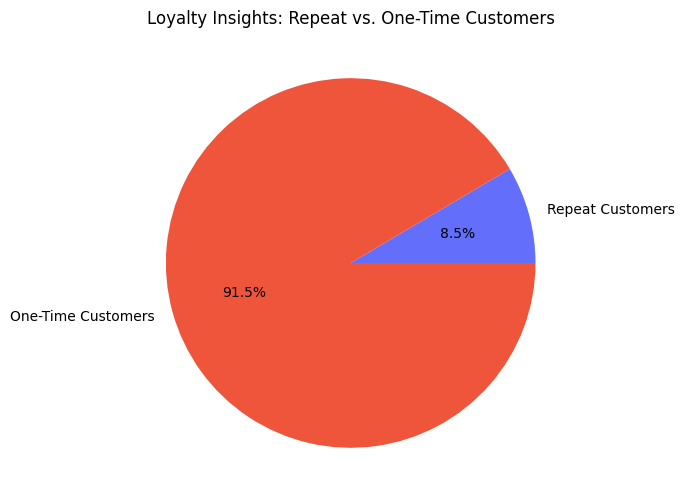

In [37]:
bookings_per_customer = bookings['customer_id'].value_counts().reset_index()

# ℹ️ Filter for repeat and one_time customers
repeat_customers = bookings_per_customer[bookings_per_customer['count'] > 1]
one_time_customers = bookings_per_customer[bookings_per_customer['count'] == 1]

# ℹ️ Create a piechart
labels = ['Repeat Customers', 'One-Time Customers']
sizes = [len(repeat_customers), len(one_time_customers)]
colors = ['#636EFA', '#EF553B']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Loyalty Insights: Repeat vs. One-Time Customers')


plt.show()

<font size=4 color=#355E3B><b>Key Insights</b></font>

* The pie chart reveals that **91.5% of customers are one-time bookers**, while only **8.5% are repeat customers**.

* This indicates a **low customer retention rate**, suggesting that most users engage with the platform only once.

* The small proportion of repeat customers highlights limited long-term loyalty and potential gaps in post-booking engagement.

* Strengthening retention strategies could significantly improve lifetime value and reduce acquisition costs.